## Library

In [ ]:
import numpy as np
import torch
import argparse
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms
from PIL import Image
from caltech_classifier import CaltechImageClassifier
from brain_tumor_classifier import BrainTumorClassifier
from sample_xAI import *
import gc

c:\Users\Hoang Bao Khanh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = 'data'
output_dir = 'outputs'
sample_output_dir = 'outputs/sample_explanation'
img_size = 224

In [ ]:
import os

# Lấy thư mục hiện tại
current_dir = os.getcwd()
print("📁 Current dir:", current_dir)

parent_dir = os.path.dirname(current_dir)

os.chdir(parent_dir)
print("⬆️  New current dir:", os.getcwd())


📁 Thư mục hiện tại: e:\KLTN\src\XAI\codes\src
⬆️  Đã lùi về: e:\KLTN\src\XAI\codes


## Explanation with model

In [ ]:
def model_explanation(img_path, data_dir, output_dir, img_size=224, dataset="brain-tumor", model_name="efficientnet_b3"):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if dataset == 'brain-tumor':
        clf = BrainTumorClassifier(data_dir=data_dir, output_dir=output_dir, img_size=img_size, args_model=model_name)
    elif dataset == 'caltech-101':
        clf = CaltechImageClassifier(data_dir=data_dir, output_dir=output_dir, img_size=img_size, args_model=model_name)
    
    clf._build_dataloaders()
    clf.load_trained_model()

    # Model prediction
    print("\n🔮 Model prediction...")

    org_image = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img_tensor = transform(org_image).unsqueeze(0).to(device)

    # Create a CPU numpy copy for methods that expect numpy inputs (e.g., LIME)
    img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # LIME
    lime_explanation, lime_heatmap = explain_with_lime(clf, img_np, clf.class_names, sample_output_dir, dataset, org_image)
    # IPEM
    ipem_heatmap = explain_with_ipem(clf, img_tensor, clf.class_names, sample_output_dir, dataset, org_image)
    # grad-cam
    gradCAM_heatmap = explain_with_gradcam(clf, img_tensor, clf.class_names, sample_output_dir, dataset, org_image)
    # rise
    rise_heatmap = explain_with_rise(clf, img_tensor, clf.class_names, sample_output_dir, dataset, org_image)

    return clf, lime_explanation, lime_heatmap, ipem_heatmap, gradCAM_heatmap, rise_heatmap, img_tensor

In [ ]:
def visualize_AOPC_MORF_score(img_path, lime_map_path, ipem_map_path, gradcam_map_path, rise_map_path, clf):
    # Giải nén kết quả
    lime_class_origin, lime_AOPC_list, lime_mean_AOPC = AOPC_MoRF(clf, lime_map_path, img_path)

    gc.collect()
    torch.cuda.empty_cache()

    ipem_class_origin, ipem_AOPC_list, ipem_mean_AOPC = AOPC_MoRF(clf, ipem_map_path, img_path)

    gc.collect()
    torch.cuda.empty_cache()

    gradcam_class_origin, gradcam_AOPC_list, gradcam_mean_AOPC = AOPC_MoRF(clf, gradcam_map_path, img_path)

    gc.collect()
    torch.cuda.empty_cache()

    rise_class_origin, rise_AOPC_list, rise_mean_AOPC = AOPC_MoRF(clf, rise_map_path, img_path)

    steps = np.arange(1, len(rise_AOPC_list) + 1)
    
    # Vẽ biểu đồ đường
    plt.figure(figsize=(8, 5))
    plt.plot(steps, lime_AOPC_list, color='red', linestyle='-', linewidth=2, label=f'LIME AOPC per step: {lime_mean_AOPC:.4f}')
    plt.plot(steps, ipem_AOPC_list, color='blue', linestyle='-', linewidth=2, label=f'IPEM AOPC per step: {ipem_mean_AOPC:.4f}')
    plt.plot(steps, gradcam_AOPC_list, color='yellow', linestyle='-', linewidth=2, label=f'GradCAM AOPC per step: {gradcam_mean_AOPC:.4f}')
    plt.plot(steps, rise_AOPC_list, color='black', linestyle='-', linewidth=2, label=f'RISE AOPC per step: {rise_mean_AOPC:.4f}')

    # Thêm tiêu đề và nhãn
    plt.title(f"AOPC MoRF Curve (Class: {clf.class_names[rise_class_origin]})")
    plt.xlabel("Perturbation Step")
    plt.ylabel("AOPC Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## Deletion and Insertion

In [6]:
def insertion_deletion_score(model, img_tensor, heatmap, target_class, steps=20, mode="insertion"):
    """
    Tính Insertion/Deletion score cho một ảnh và heatmap.
    - img_tensor: torch.Tensor, shape (C,H,W) or (1,C,H,W), ảnh gốc.
    - heatmap: numpy array, shape (H,W) or (H,W,C), heatmap giải thích.
    - target_class: int, lớp mục tiêu để theo dõi xác suất.
    - steps: số bước perturbation.
    - mode: "insertion" hoặc "deletion".
    Trả về AUC score.
    """
    device = next(model.parameters()).device

    # Chuẩn bị transform (not used directly here but kept for compatibility)
    transform = transforms.Compose([
        transforms.Resize((img_tensor.shape[1] if img_tensor.dim() > 2 else img_tensor.shape[2], img_tensor.shape[2] if img_tensor.dim() > 2 else img_tensor.shape[1])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Chuẩn bị ảnh nền (baseline = all-zero) used for both insertion and deletion
    baseline = torch.zeros_like(img_tensor).to(device)

    # Chuẩn bị heatmap: validate and convert to single-channel
    hm = np.array(heatmap)
    if hm.size == 0:
        raise ValueError("Heatmap is empty or invalid for resizing")
    # If heatmap has channels (e.g., C,H,W or H,W,C), average to single channel
    if hm.ndim == 3:
        # try to detect channel-first (C,H,W) or channel-last (H,W,C)
        if hm.shape[0] <= 4 and hm.shape[0] != hm.shape[1]:
            # likely (C,H,W)
            hm = hm.mean(axis=0)
        else:
            # likely (H,W,C)
            hm = hm.mean(axis=2)
    # Replace NaN/inf with zeros
    hm = np.nan_to_num(hm, nan=0.0, posinf=0.0, neginf=0.0)
    # Normalize to [0,1] if possible
    if hm.max() - hm.min() > 0:
        hm = (hm - hm.min()) / (hm.max() - hm.min())
    else:
        hm = np.zeros_like(hm)

    # Resize heatmap to match image size
    # Determine target width/height from img_tensor shape
    if img_tensor.dim() == 4:
        _, C, H, W = img_tensor.shape
    elif img_tensor.dim() == 3:
        C, H, W = img_tensor.shape
    else:
        raise ValueError(f"Unsupported img_tensor shape: {img_tensor.shape}")

    target_w, target_h = int(W), int(H)
    try:
        # cv2.resize expects (width, height); convert to uint8 to avoid issues
        heatmap_resized = cv2.resize((hm * 255).astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    except Exception as e:
        raise RuntimeError(f"Failed to resize heatmap: {e}")

    heatmap_flat = heatmap_resized.flatten()
    indices = np.argsort(-heatmap_flat)  # sắp xếp giảm dần

    # Tính xác suất qua các bước
    probs = []
    for step in range(steps + 1):
        fraction = step / steps
        num_pixels = int(fraction * len(heatmap_flat))

        mask = np.zeros_like(heatmap_flat)
        mask[indices[:num_pixels]] = 1.0
        mask = mask.reshape(heatmap_resized.shape)

        # Tạo mask tensor với dạng phù hợp để broadcast
        mask_t = torch.tensor(mask, dtype=img_tensor.dtype, device=device)
        if img_tensor.dim() == 4:
            # make shape (1,1,H,W) so it broadcasts to (1,C,H,W)
            mask_t = mask_t.unsqueeze(0).unsqueeze(1)
        else:
            # img_tensor dim==3 (C,H,W) -> make mask (1,H,W) which will broadcast across channels
            mask_t = mask_t.unsqueeze(0)

        # Tạo ảnh perturbed
        if mode == "insertion":
            # start from baseline and insert pixels from original
            perturbed_img = baseline * (1 - mask_t) + img_tensor * mask_t
        else:  # deletion
            # start from original and replace masked pixels with baseline
            perturbed_img = img_tensor * (1 - mask_t) + baseline * mask_t

        # Ensure perturbed_img has batch dimension when passing to model
        if perturbed_img.dim() == 3:
            perturbed_in = perturbed_img.unsqueeze(0)
        else:
            perturbed_in = perturbed_img

        with torch.no_grad():
            output = model(perturbed_in)
            prob = torch.softmax(output, dim=1)[0, target_class].item()

        probs.append(prob)
    # Tính AUC
    auc_score = np.trapezoid(probs, dx=1.0/steps)
    return auc_score, probs

In [7]:
def plot_insertion_deletion_curve(
    model,
    img_tensor,
    lime_heatmap,
    ipem_heatmap,
    gradcam_heatmap,
    rise_heatmap,
    target_class,
    dataset,
    steps=20
):
    methods = {
        "LIME": lime_heatmap,
        "IPEM": ipem_heatmap,
        "Grad-CAM": gradcam_heatmap,
        "RISE": rise_heatmap,
    }

    x = np.linspace(0, 1, steps + 1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

    for col, (name, heatmap) in enumerate(methods.items()):
        # ---------- Deletion ----------
        auc_del, probs_del = insertion_deletion_score(
            model, img_tensor, heatmap, target_class, steps, mode="deletion"
        )

        axes[0, col].plot(x, probs_del)
        axes[0, col].fill_between(x, probs_del, color="lightblue", alpha=0.3)
        axes[0, col].set_title(f"{name}\nAUC={auc_del:.3f}")
        axes[0, col].grid(True)

        if col == 0:
            axes[0, col].set_ylabel("Deletion\nTarget prob")

        # ---------- Insertion ----------
        auc_ins, probs_ins = insertion_deletion_score(
            model, img_tensor, heatmap, target_class, steps, mode="insertion"
        )

        axes[1, col].plot(x, probs_ins)
        axes[1, col].fill_between(x, probs_ins, color="lightblue", alpha=0.3)
        axes[1, col].set_title(f"{name}\nAUC={auc_ins:.3f}")
        axes[1, col].grid(True)

        if col == 0:
            axes[1, col].set_ylabel("Insertion\nTarget prob")

        axes[1, col].set_xlabel("Fraction of pixels")

    # plt.suptitle(f"Insertion–Deletion Curves Comparison - {dataset}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"ins_del_{dataset}.jpg")
    plt.show()


## Brain tumor

True


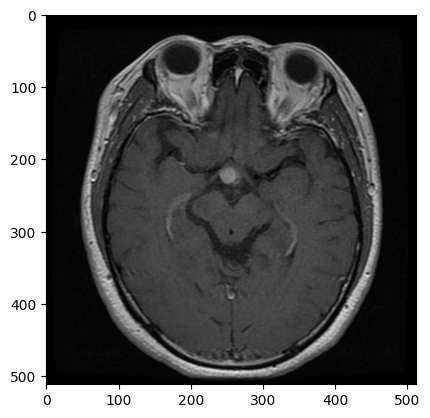

In [8]:
import os

img_path = os.path.join(parent_dir, 'data/brain-tumor/Testing/pituitary/Te-pi_25.jpg')
print(os.path.exists(img_path))
animal_img = cv2.imread(img_path)
img = cv2.cvtColor(animal_img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Explanation with Efficientnet B3


🔮 Dự đoán với mô hình...
   - Tạo thư mục: outputs\sample_explanation\brain-tumor\lime
🔍 Đang chạy LIME...
   - Input shape: (224, 224, 3)
   - Output dir: outputs/sample_explanation/brain-tumor


100%|██████████| 2000/2000 [00:11<00:00, 173.72it/s]


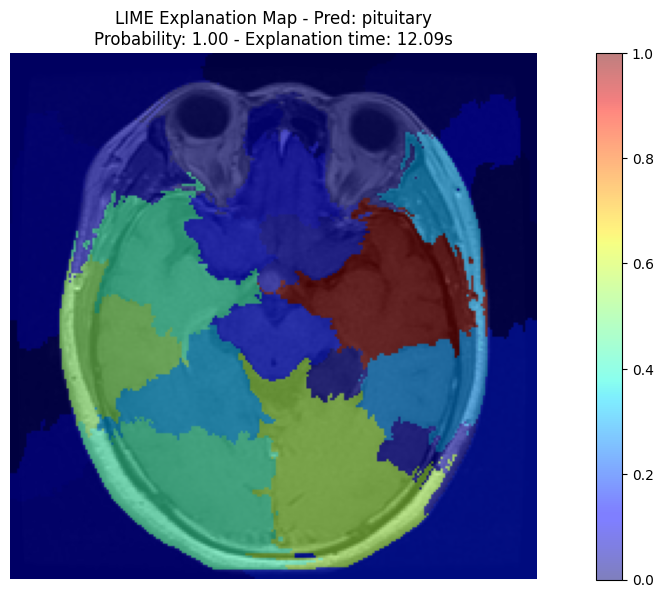

🔍 Đang chạy IPEM...


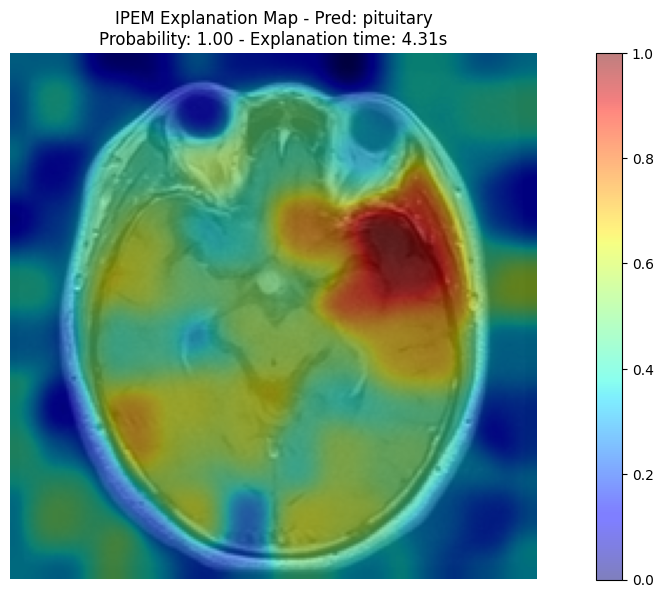

🔍 Đang chạy GradCAM...


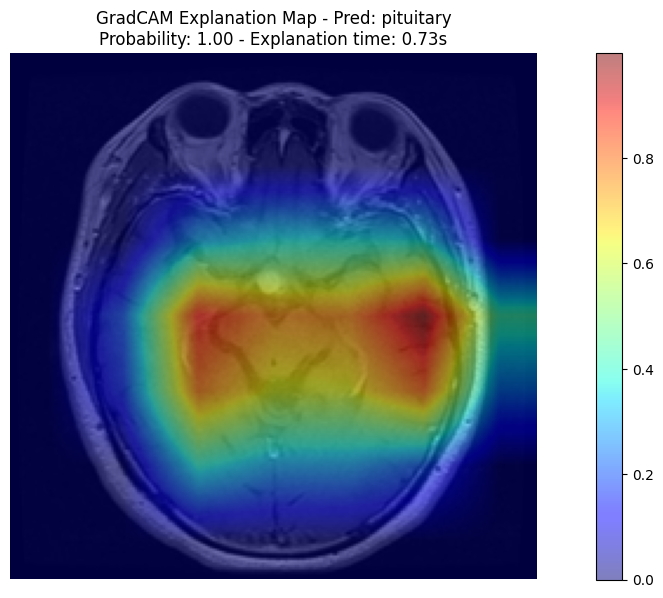

🔍 Đang chạy RISE...


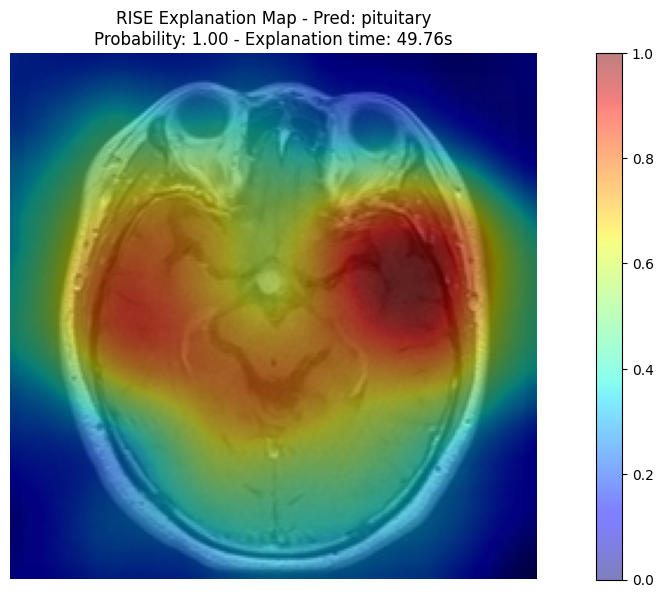

In [9]:
clf, brain_tumor_lime_explanation, brain_tumor_lime_mask, brain_tumor_ipem_heatmap, brain_tumor_gradCAM_heatmap, brain_tumor_rise_heatmap, brain_tumor_img_tensor = model_explanation(img_path, data_dir, output_dir, img_size=224, dataset="brain-tumor", model_name="efficientnet_b3")

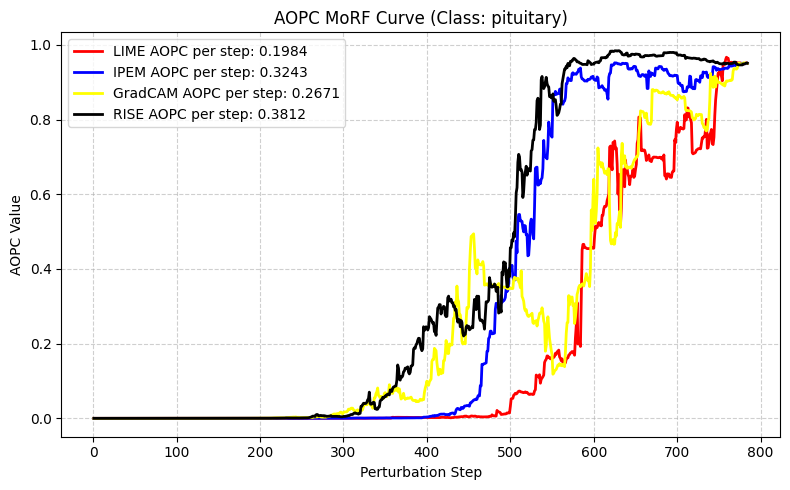

In [10]:
lime_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/lime/LIME_mask.png')
# shap_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/shap/SHAP_mask.png')
ipem_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/ipem/IPEM_mask.png')
gradcam_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/GradCAM/GradCAM_mask.png')
rise_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/RISE/RISE_mask.png')
# shapleycam_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/brain-tumor/ShapleyCAM/ShapleyCAM_mask.png')
gc.collect()
torch.cuda.empty_cache()
visualize_AOPC_MORF_score(img_path, lime_map_path, ipem_map_path, gradcam_map_path, rise_map_path, clf)

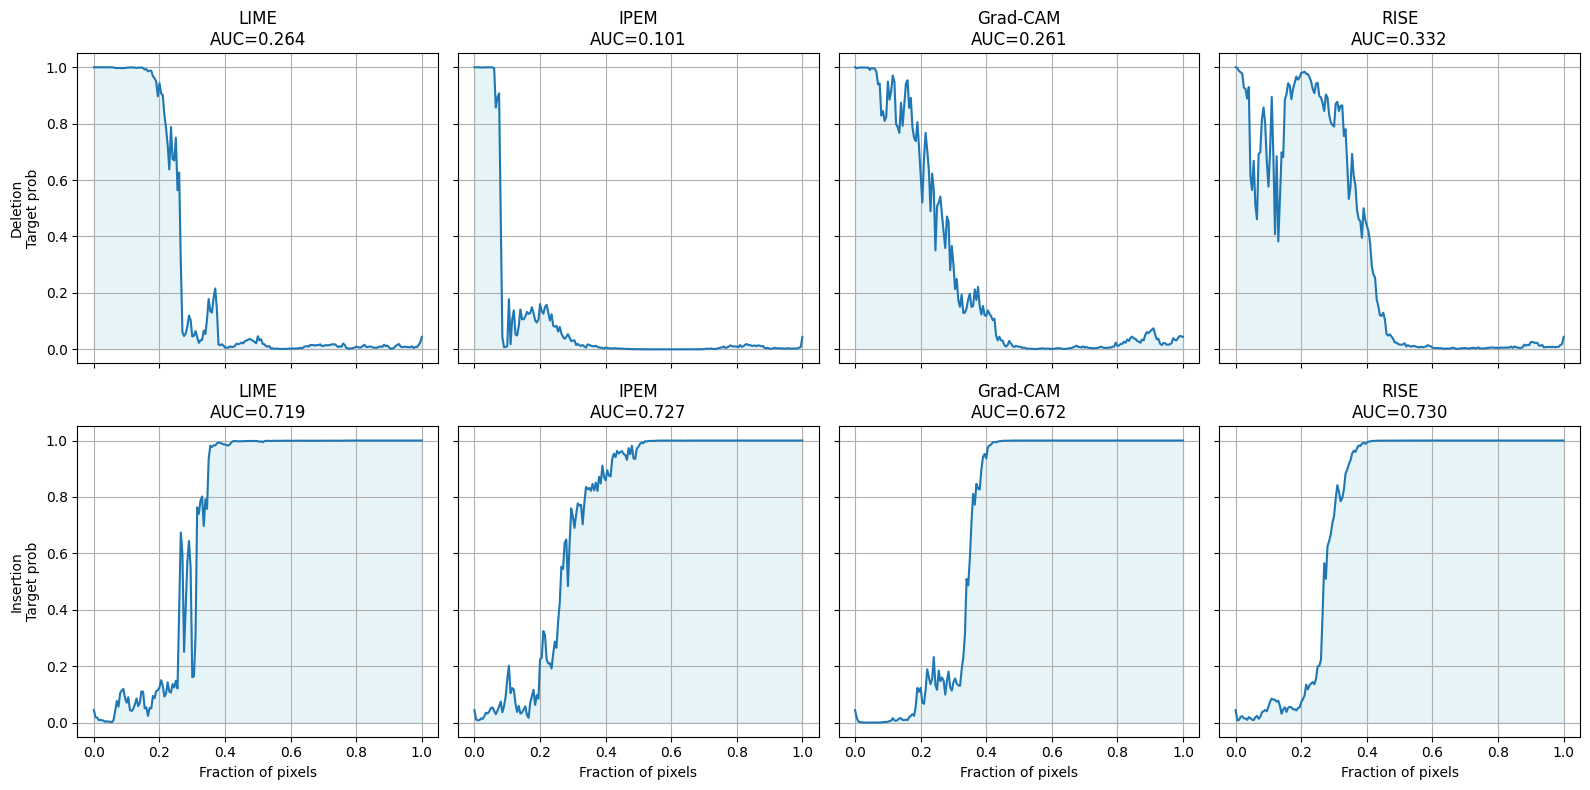

In [11]:
pred_class, _, _ = predict_with_model(clf.model, brain_tumor_img_tensor)
target_idx = int(pred_class)

plot_insertion_deletion_curve(
    clf.model,
    brain_tumor_img_tensor,
    brain_tumor_lime_mask,
    brain_tumor_ipem_heatmap,
    brain_tumor_gradCAM_heatmap,
    brain_tumor_rise_heatmap,
    target_idx,
    dataset="Brain Tumor",
    steps=200,
)

gc.collect()
torch.cuda.empty_cache()

### Caltech-101

True


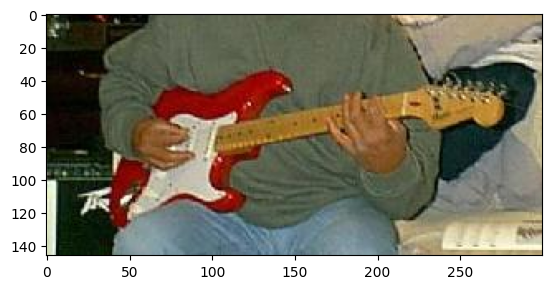

In [12]:
gc.collect()
torch.cuda.empty_cache()


import os

img_path = os.path.join(parent_dir, 'data\caltech-101\\electric_guitar\\image_0058.jpg')
print(os.path.exists(img_path))
animal_img = cv2.imread(img_path)
img = cv2.cvtColor(animal_img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Explanation with Efficientnet B3


🔮 Dự đoán với mô hình...
   - Tạo thư mục: outputs\sample_explanation\caltech-101\lime
🔍 Đang chạy LIME...
   - Input shape: (224, 224, 3)
   - Output dir: outputs/sample_explanation/caltech-101


100%|██████████| 2000/2000 [00:12<00:00, 160.69it/s]


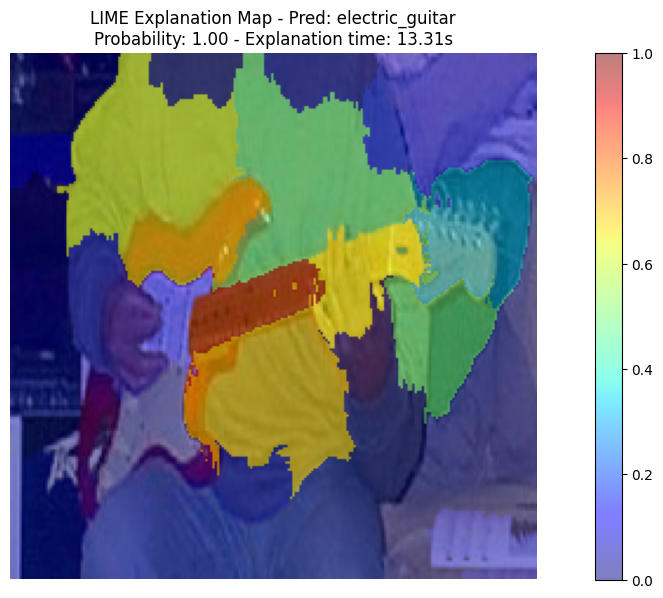

🔍 Đang chạy IPEM...


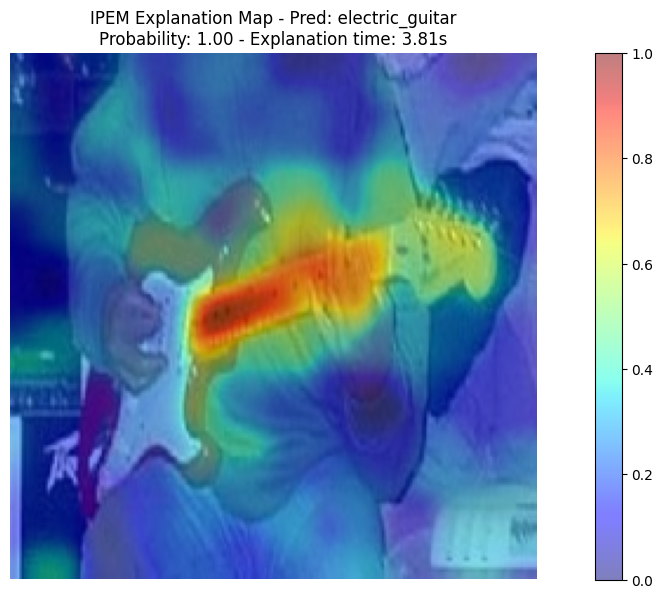

🔍 Đang chạy GradCAM...


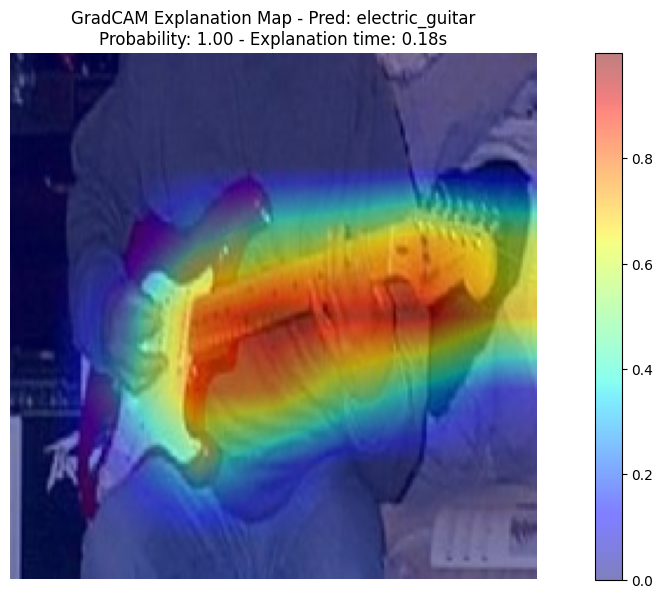

🔍 Đang chạy RISE...


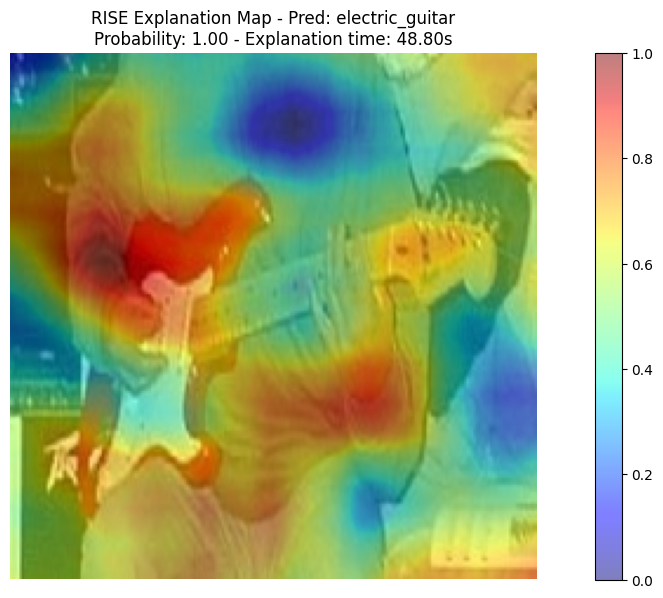

In [13]:
clf, caltech_lime_explanation, caltech_lime_mask, caltech_ipem_heatmap, caltech_gradCAM_heatmap, caltech_rise_heatmap, caltech_img_tensor = model_explanation(img_path, data_dir, output_dir, img_size=224, dataset="caltech-101", model_name="efficientnet_b3")   

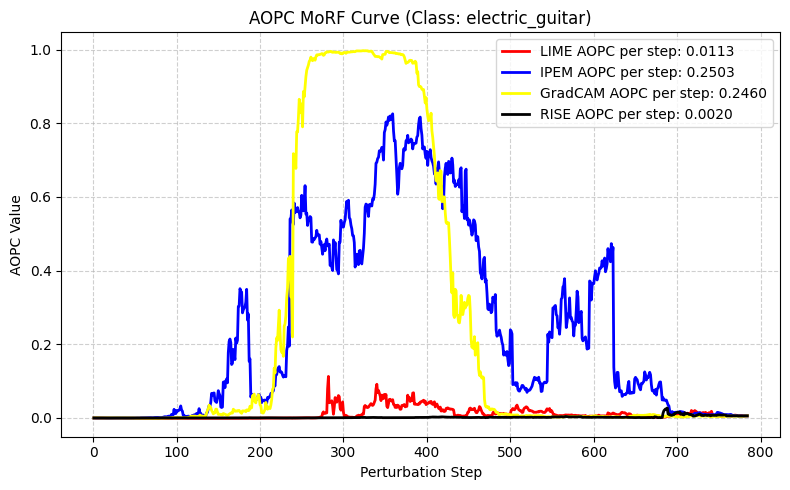

In [14]:
lime_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/lime/LIME_mask.png')
# shap_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/shap/SHAP_mask.png')
ipem_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/ipem/IPEM_mask.png')
gradcam_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/GradCAM/GradCAM_mask.png')
rise_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/RISE/RISE_mask.png')

gc.collect()
torch.cuda.empty_cache()
visualize_AOPC_MORF_score(img_path, lime_map_path, ipem_map_path, gradcam_map_path, rise_map_path, clf)


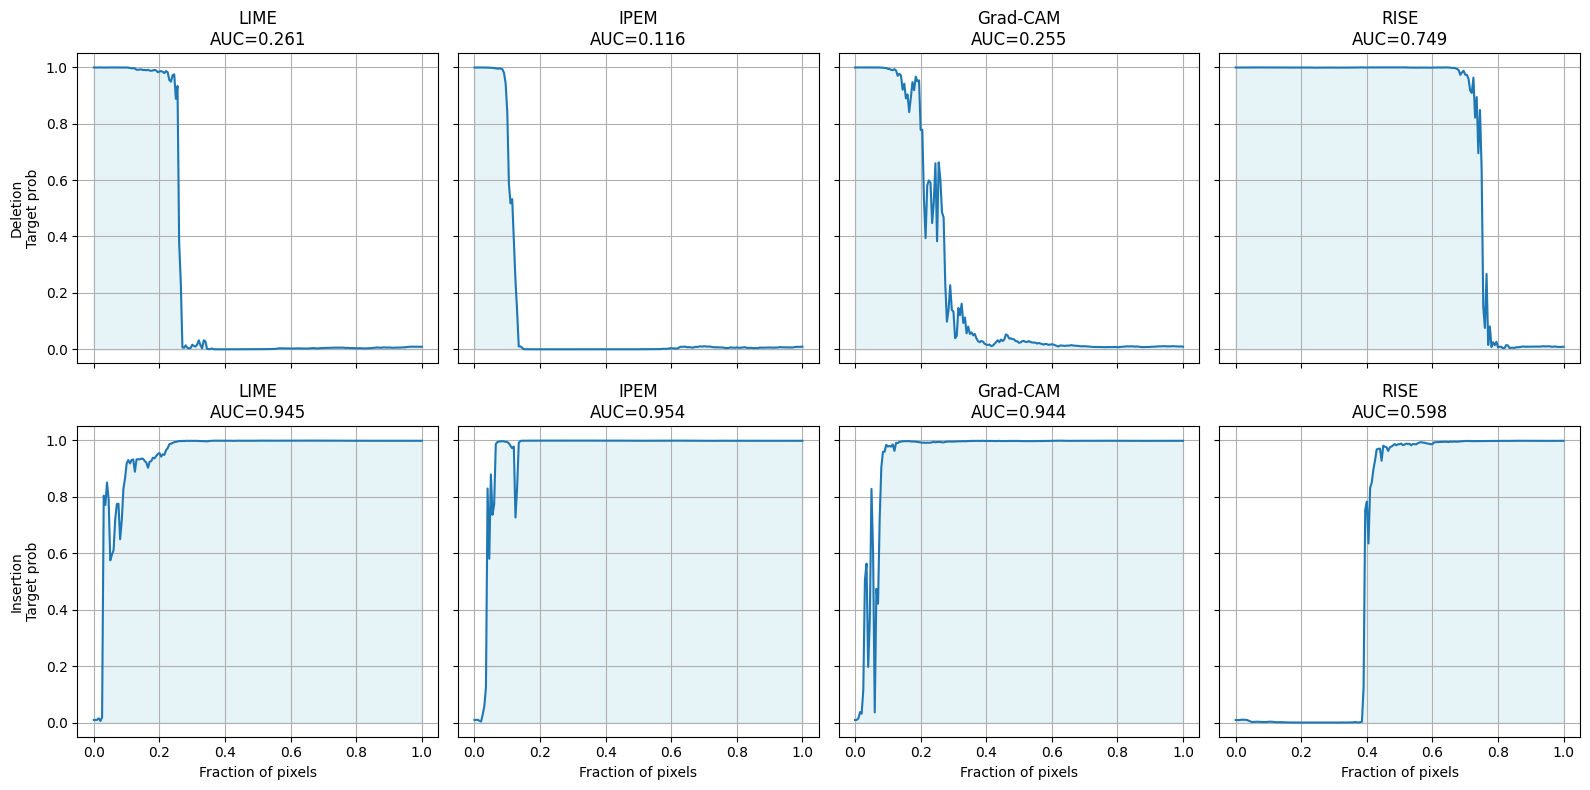

In [15]:
gc.collect()
torch.cuda.empty_cache()


pred_class, _, _ = predict_with_model(clf.model, caltech_img_tensor)
target_idx = int(pred_class)

plot_insertion_deletion_curve(
    clf.model,
    caltech_img_tensor,
    caltech_lime_mask,
    caltech_ipem_heatmap,
    caltech_gradCAM_heatmap,
    caltech_rise_heatmap,
    target_idx,
    dataset="Caltech-101",
    steps=200,
)